<a href="https://colab.research.google.com/github/Averydo23/Problem_set_2/blob/main/Problem_Set__2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part 1: Dataset Overview

The data comprises 2,335 reviews across 12 UK fashion brands collected
between January 2024 and March 2026 from Trustpilot reviews. This section loads the scraped Trustpilot dataset, applies text cleaning, and maps star ratings to sentiment labels (Positive/Neutral/Negative).


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re, warnings
warnings.filterwarnings("ignore")

# Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set the path to your data folder
DATA_DIR = '/content/drive/MyDrive/Problem Set 2/data'

import os
print('Files in data directory:')
print(os.listdir(DATA_DIR))

df = pd.read_csv(f'{DATA_DIR}/reviews_raw.csv')
print(f"Loaded {len(df):,} reviews")
print(df["sentiment"].value_counts())

Mounted at /content/drive
Files in data directory:
['reviews_raw.csv', 'Data_scrape_from_Trustpilot.ipynb', 'Problem_Set _2.ipynb']
Loaded 2,335 reviews
sentiment
Negative    1795
Positive     476
Neutral       64
Name: count, dtype: int64


In [3]:
# Basic text cleaning
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_clean"] = df["review_text"].apply(clean_text)
df = df[df["text_clean"].str.split().str.len() >= 5].reset_index(drop=True)

print(f"Total: {len(df):,} reviews | {df['brand'].nunique()} brands")
print(df["sentiment"].value_counts())

Total: 2,333 reviews | 12 brands
sentiment
Negative    1794
Positive     475
Neutral       64
Name: count, dtype: int64


In [29]:
brand_sentiment = df.groupby("brand")["sentiment"].value_counts(normalize=True).mul(100).round(1).unstack(fill_value=0)
print(brand_sentiment[["Negative", "Neutral", "Positive"]])

sentiment          Negative  Neutral  Positive
brand                                         
ASOS                   97.9      1.0       1.0
Boohoo                 84.0      0.5      15.5
HM                     84.3      5.1      10.7
InTheStyle             74.0      2.5      23.5
Missguided             96.0      1.0       3.0
NastyGal               68.8      1.5      29.6
NewLook                86.4      3.0      10.6
Next                   15.7      5.6      78.7
PrettyLittleThing      63.9      2.6      33.5
RiverIsland            84.3      2.0      13.7
SHEIN                  73.1      6.0      20.9
Zara                   88.1      2.6       9.3


### Train test split

In [4]:
from sklearn.model_selection import train_test_split

X = df["text_clean"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print("\nClass distribution in training set:")
print(y_train.value_counts())

Train: 1,866  |  Test: 467

Class distribution in training set:
sentiment
Negative    1435
Positive     380
Neutral       51
Name: count, dtype: int64


## Part 2: Baseline Models
Two baseline approaches are evaluated: TF-IDF + Logistic Regression with
GridSearchCV hyperparameter tuning, and Sentence Embeddings + Logistic
Regression using all-MiniLM-L6-v2. Both serve as performance benchmarks
for the fine-tuned transformer model in Part 3.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, classification_report, accuracy_score

# TF-IDF — fit on train ONLY (no data leakage)
vectorizer = TfidfVectorizer(stop_words="english", max_features=10000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)
print(f"Vocabulary size: {len(vectorizer.vocabulary_):,}")
print(f"Training matrix shape: {X_train_tfidf.shape}")

# GridSearchCV — tune C
param_grid = {"C": [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    param_grid, scoring="f1_macro", cv=5, verbose=1
)
grid.fit(X_train_tfidf, y_train)

print(f"Best C: {grid.best_params_['C']} | CV Macro F1: {grid.best_score_:.4f}")

y_pred_tfidf = grid.predict(X_test_tfidf)

# Overall metrics
print("Validation Set Performance")
print("=" * 50)
print(f"Test Macro F1:    {f1_score(y_test, y_pred_tfidf, average='macro'):.4f}")
print(f"Test Weighted F1: {f1_score(y_test, y_pred_tfidf, average='weighted'):.4f}")
print(f"Accuracy:    {accuracy_score(y_test, y_pred_tfidf):.4f}")
print("\nPer-class breakdown:")
print(classification_report(y_test, y_pred_tfidf))

Vocabulary size: 10,000
Training matrix shape: (1866, 10000)
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best C: 0.01 | CV Macro F1: 0.6573
Validation Set Performance
Test Macro F1:    0.6746
Test Weighted F1: 0.9180
Accuracy:    0.9165

Per-class breakdown:
              precision    recall  f1-score   support

    Negative       0.95      0.97      0.96       359
     Neutral       0.19      0.23      0.21        13
    Positive       0.90      0.82      0.86        95

    accuracy                           0.92       467
   macro avg       0.68      0.67      0.67       467
weighted avg       0.92      0.92      0.92       467



## Part 2: Fine-tuned DistilBERT
DistilBERT-base-uncased is fine-tuned on the training set using the
Hugging Face Trainer API. Selected as the final model for downstream
competitor analysis due to its contextual understanding of informal
consumer language, producing cleaner Negative classifications for
BERTopic clustering.

In [11]:
# Check if GPU is available
import torch
if torch.cuda.is_available():
    print(f'GPU available: {torch.cuda.get_device_name(0)}')
else:
    print('No GPU detected. Go to Runtime > Change runtime type > T4 GPU')

GPU available: Tesla T4


In [12]:
# sentence-transformers is needed for the comparison section later
!pip install sentence-transformers -q

In [13]:
from transformers import (AutoTokenizer,
                           AutoModelForSequenceClassification,
                           Trainer, TrainingArguments)
from datasets import Dataset

# Suppress some warnings
import warnings
warnings.filterwarnings('ignore')
import logging
logging.basicConfig(level=logging.WARNING)

In [15]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

LABEL_MAP   = {"Negative": 0, "Neutral": 1, "Positive": 2}
LABEL_NAMES = ["Negative", "Neutral", "Positive"]

def make_dataset(texts, labels):
    ds = Dataset.from_dict({
        "text" : texts.tolist(),
        "label": [LABEL_MAP[l] for l in labels]
    })
    return ds.map(
        lambda x: tokenizer(x["text"], truncation=True,
                             padding="max_length", max_length=128),
        batched=True
    )

train_ds = make_dataset(X_train, y_train)
test_ds  = make_dataset(X_test,  y_test)

# ── Fine-tune DistilBERT
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=3
)
args = TrainingArguments(
    output_dir="./results_distilbert",
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="no",
    report_to="none"
)
trainer = Trainer(model=model, args=args,
                  train_dataset=train_ds, eval_dataset=test_ds)
trainer.train()

# ── Results
output     = trainer.predict(test_ds)
y_pred_dis = [LABEL_NAMES[i] for i in np.argmax(output.predictions, axis=1)]
print(f"\nDistilBERT — Test Macro F1: {f1_score(y_test, y_pred_dis, average='macro'):.4f}")
print(f"\nDistilBERT — Test Weighted F1: {f1_score(y_test, y_pred_dis, average='weighted'):.4f}")
print(classification_report(y_test, y_pred_dis))

Map:   0%|          | 0/1866 [00:00<?, ? examples/s]

Map:   0%|          | 0/467 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,No log,0.264760
2,No log,0.245408



DistilBERT — Test Macro F1: 0.6207

DistilBERT — Test Weighted F1: 0.9241
              precision    recall  f1-score   support

    Negative       0.94      0.99      0.96       359
     Neutral       0.00      0.00      0.00        13
    Positive       0.92      0.87      0.90        95

    accuracy                           0.94       467
   macro avg       0.62      0.62      0.62       467
weighted avg       0.91      0.94      0.92       467



## Part 3: Model Comparison & Confusion Matrix
All three models are compared on Accuracy, Macro F1, and Weighted F1.
Error analysis examines DistilBERT misclassifications to identify failure
patterns and their connection to BERTopic outliers.

          Model  Accuracy  Macro F1  Weighted F1
TF-IDF + LogReg    0.9165    0.6746       0.9180
     DistilBERT    0.9379    0.6207       0.9241


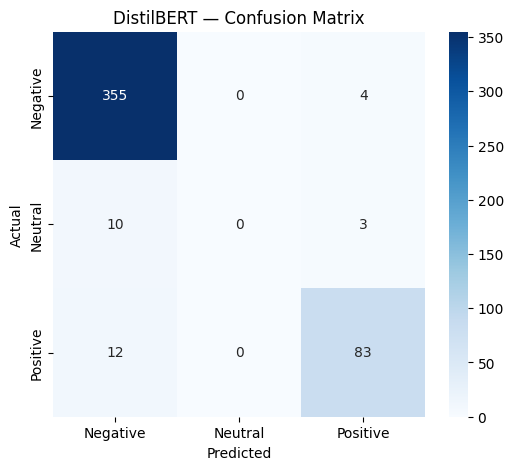

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Comparison table  all models
results = []
for name, y_pred in [
    ("TF-IDF + LogReg",     y_pred_tfidf),
    ("DistilBERT",          y_pred_dis),
]:
    results.append({
        "Model":       name,
        "Accuracy":    round(accuracy_score(y_test, y_pred), 4),
        "Macro F1":    round(f1_score(y_test, y_pred, average="macro"), 4),
        "Weighted F1": round(f1_score(y_test, y_pred, average="weighted"), 4),
    })
print(pd.DataFrame(results).to_string(index=False))

# Confusion Matrix — final model DistilBERT
cm = confusion_matrix(y_test, y_pred_dis,
                      labels=["Negative","Neutral","Positive"])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative","Neutral","Positive"],
            yticklabels=["Negative","Neutral","Positive"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("DistilBERT — Confusion Matrix")
plt.show()

## Part 4: Error Analysis

To understand the limitations of our final model, we examine cases where DistilBERT
misclassified reviews. This analysis examines DistilBERT misclassifications to identify failure
patterns and their connection to BERTopic outliers.


In [17]:
import torch.nn.functional as F

def predict_sentiment(texts):
    inputs = tokenizer(texts, truncation=True, padding=True,
                      max_length=128, return_tensors='pt')
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        logits = model(**inputs).logits

    probs = F.softmax(logits, dim=1).cpu().numpy()
    preds = np.argmax(probs, axis=1)
    return preds, probs

# Error Analysis — lấy reviews DistilBERT predict sai
test_df = X_test.to_frame().copy()
test_df["true"]      = y_test.values
test_df["predicted"] = y_pred_dis

errors = test_df[test_df["true"] != test_df["predicted"]]
print(f"Misclassified: {len(errors)} / {len(test_df)} ({100*len(errors)/len(test_df):.1f}%)")

Misclassified: 29 / 467 (6.2%)


In [18]:
# Show 5 examples with confidence scores
sample_errors = errors.sample(5, random_state=42)
preds, probs = predict_sentiment(sample_errors["text_clean"].tolist())

print("\nSample misclassifications:")
print("=" * 70)
for i, (_, row) in enumerate(sample_errors.iterrows()):
    conf = probs[i].max() * 100
    print(f"Text     : {row['text_clean'][:80]}...")
    print(f"True     : {row['true']} | Predicted: {row['predicted']} | Confidence: {conf:.1f}%\n")


Sample misclassifications:
Text     : i brought some merchandise from shein and there carrier service which is speedx ...
True     : Neutral | Predicted: Negative | Confidence: 98.5%

Text     : shein is honestly hit or miss most times i ve been shopping on shein for roughly...
True     : Neutral | Predicted: Negative | Confidence: 97.8%

Text     : large range of brands and easy returns...
True     : Neutral | Predicted: Positive | Confidence: 94.6%

Text     : surrey quays store has the least helpful staff members i ve ever come across gla...
True     : Negative | Predicted: Positive | Confidence: 93.0%

Text     : i have been a customer of next for years majority of my purchases have been made...
True     : Positive | Predicted: Negative | Confidence: 61.5%



## Part 5: Competitor Analysis through BERTopic

BERTopic is applied exclusively to Negative reviews (n=1,794) to
automatically discover complaint themes across brands. Topics are merged
into macro-themes via hierarchical clustering, then mapped per brand to
generate actionable business recommendations.


In [19]:
!pip install bertopic sentence-transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.3 MB/s eta 0:00:00


In [20]:
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

In [21]:
# Dùng toàn bộ Negative reviews từ df gốc — nhiều data hơn cho BERTopic
neg_df      = df[df["sentiment"] == "Negative"].reset_index(drop=True)
neg_reviews = neg_df["text_clean"].tolist()
neg_brands  = neg_df["brand"].tolist()
print(f"Total Negative reviews: {len(neg_reviews):,}")
print(neg_df["brand"].value_counts())

Total Negative reviews: 1,794
brand
ASOS                 191
Missguided           191
NewLook              171
Zara                 171
Boohoo               168
RiverIsland          166
HM                   166
InTheStyle           148
NastyGal             137
SHEIN                133
PrettyLittleThing    124
Next                  28
Name: count, dtype: int64


In [22]:
# Step 1: Pre-compute embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
print("Encoding negative reviews...")
embeddings = embedding_model.encode(neg_reviews, show_progress_bar=True)
print(f"Embeddings shape: {embeddings.shape}")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding negative reviews...


Batches:   0%|          | 0/57 [00:00<?, ?it/s]

Embeddings shape: (1794, 384)


In [23]:
from umap import UMAP
from hdbscan import HDBSCAN

# Tune parameters to reduce outliers
umap_model    = UMAP(n_neighbors=15, n_components=5,
                     min_dist=0.0, metric="cosine", random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=10, min_samples=3,
                         prediction_data=True)

vectorizer_model     = CountVectorizer(stop_words="english", min_df=2, ngram_range=(1,2))
representation_model = KeyBERTInspired()

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    verbose=True
)

topics, probs = topic_model.fit_transform(neg_reviews, embeddings=embeddings)

topic_info = topic_model.get_topic_info()
outlier_count = topic_info[topic_info["Topic"]==-1]["Count"].values[0]
print(f"Outliers: {outlier_count} / {len(neg_reviews)} ({100*outlier_count/len(neg_reviews):.1f}%)")
print(f"Topics found: {len(topic_info)-1}")
print(topic_info[["Topic","Count","Representation"]].head(15))

2026-03-25 17:53:38,917 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-25 17:53:58,131 - BERTopic - Dimensionality - Completed ✓
2026-03-25 17:53:58,133 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-25 17:53:58,338 - BERTopic - Cluster - Completed ✓
2026-03-25 17:53:58,352 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-25 17:54:00,847 - BERTopic - Representation - Completed ✓


Outliers: 524 / 1794 (29.2%)
Topics found: 50
    Topic  Count                                     Representation
0      -1    524  [shipping, refund, delivery, refunded, parcel,...
1       0     88  [refund, refunded, refunds, online order, cust...
2       1     75  [company ordered, delivery, customer service, ...
3       2     73  [contacted customer, delivery service, deliver...
4       3     58  [refund, customer service, refunded, returned ...
5       4     50  [refund customer, refund contacted, received r...
6       5     42  [return costs, return, shop, ve ordered, order...
7       6     39  [return refund, awful customer, horrible custo...
8       7     37  [received parcel, customer service, worst cust...
9       8     37  [refund, refund just, return order, trying ret...
10      9     35  [refund, don refund, months refund, refund pro...
11     10     34  [refund, chasing refund, customer service, ret...
12     11     31  [refund, returned item, month refund, pay retu...
13

In [24]:
print(topic_info[["Topic", "Count", "Representation"]].to_string())

    Topic  Count                                                                                                                                                            Representation
0      -1    524                                                                 [shipping, refund, delivery, refunded, parcel, day delivery, customer service, package, delivered, order]
1       0     88                                                              [refund, refunded, refunds, online order, customer service, complaint, customers, return, customer, service]
2       1     75                                                                    [company ordered, delivery, customer service, arrive, refund, refunded, ordered, order, arrived, mail]
3       2     73                                           [contacted customer, delivery service, delivery, asos customer, customer service, refund, ordered, order, delivered, complaint]
4       3     58                                             [ref

In [30]:
topic_model.visualize_hierarchy()

In [26]:
neg_df["topic"] = topics


def map_macro_topic(topic_id):
    if topic_id in [35, 40, 42, 47]:
        return "Refund Complaints"
    elif topic_id in [14, 28, 24, 15, 23]:
        return "Delivery Issues"
    elif topic_id in [45, 9, 3, 32, 1, 4, 7, 11, 6, 36, 25, 37, 29, 46, 41, 10, 20, 31, 39]:
        return "Refund & Customer Service"
    elif topic_id in [22, 12, 33, 26, 27]:
        return "Return & Order Issues"
    elif topic_id in [21, 34, 0, 2, 44, 18, 13, 48, 49]:
        return "Poor Customer Service"
    elif topic_id in [30, 8, 16, 19, 5, 38, 43]:
        return "Return Costs & Boycott"
    else:
        return "Other"

neg_df["topic"] = topics
neg_df["macro_topic"] = neg_df["topic"].apply(map_macro_topic)
print(neg_df["macro_topic"].value_counts())

macro_topic
Other                        547
Refund & Customer Service    524
Poor Customer Service        284
Return Costs & Boycott       170
Delivery Issues              116
Return & Order Issues        104
Refund Complaints             49
Name: count, dtype: int64


In [27]:
# Per-brand breakdown
brand_topics = neg_df.groupby(["brand", "macro_topic"]).size().unstack(fill_value=0)
print(brand_topics)

macro_topic        Delivery Issues  Other  Poor Customer Service  \
brand                                                              
ASOS                             6     39                     84   
Boohoo                           4     56                      7   
HM                              29     48                     23   
InTheStyle                      12     39                      2   
Missguided                       3     64                      1   
NastyGal                         6     53                      5   
NewLook                          7     58                     18   
Next                            10      7                      4   
PrettyLittleThing               13     51                      2   
RiverIsland                      2     42                     37   
SHEIN                           22     53                     12   
Zara                             2     37                     89   

macro_topic        Refund & Customer Service  R

In [35]:
print("=" * 60)
print("RAW TOPICS PER BRAND (top 5 topics)")
print("=" * 60)

for brand in sorted(neg_df["brand"].unique()):
    brand_data = neg_df[neg_df["brand"] == brand]
    topic_counts = brand_data[brand_data["topic"] != -1]["topic"].value_counts().head(5)

    print(f"\n{brand}")
    print("-" * 50)
    for topic_id, count in topic_counts.items():
        words = [w for w, _ in topic_model.get_topic(topic_id)[:5]]
        print(f"  Topic {topic_id:>2} ({count:>3} reviews): {', '.join(words)}")

RAW TOPICS PER BRAND (top 5 topics)

ASOS
--------------------------------------------------
  Topic  2 ( 70 reviews): contacted customer, delivery service, delivery, asos customer, customer service
  Topic 25 (  9 reviews): customer service, receive refund, terrible customer, customer support, refund
  Topic 44 (  8 reviews): refusing refund, refund, customer service, complaint, customer
  Topic  5 (  6 reviews): return costs, return, shop, ve ordered, ordered
  Topic  3 (  5 reviews): refund, customer service, refunded, returned items, customer services

Boohoo
--------------------------------------------------
  Topic 10 ( 30 reviews): refund, chasing refund, customer service, returned items, service awful
  Topic 40 ( 12 reviews): refunded customer, refund scam, refunds issued, refund, expected refund
  Topic  4 ( 11 reviews): refund customer, refund contacted, received refund, refund processed, waiting refund
  Topic  1 (  9 reviews): company ordered, delivery, customer service, a

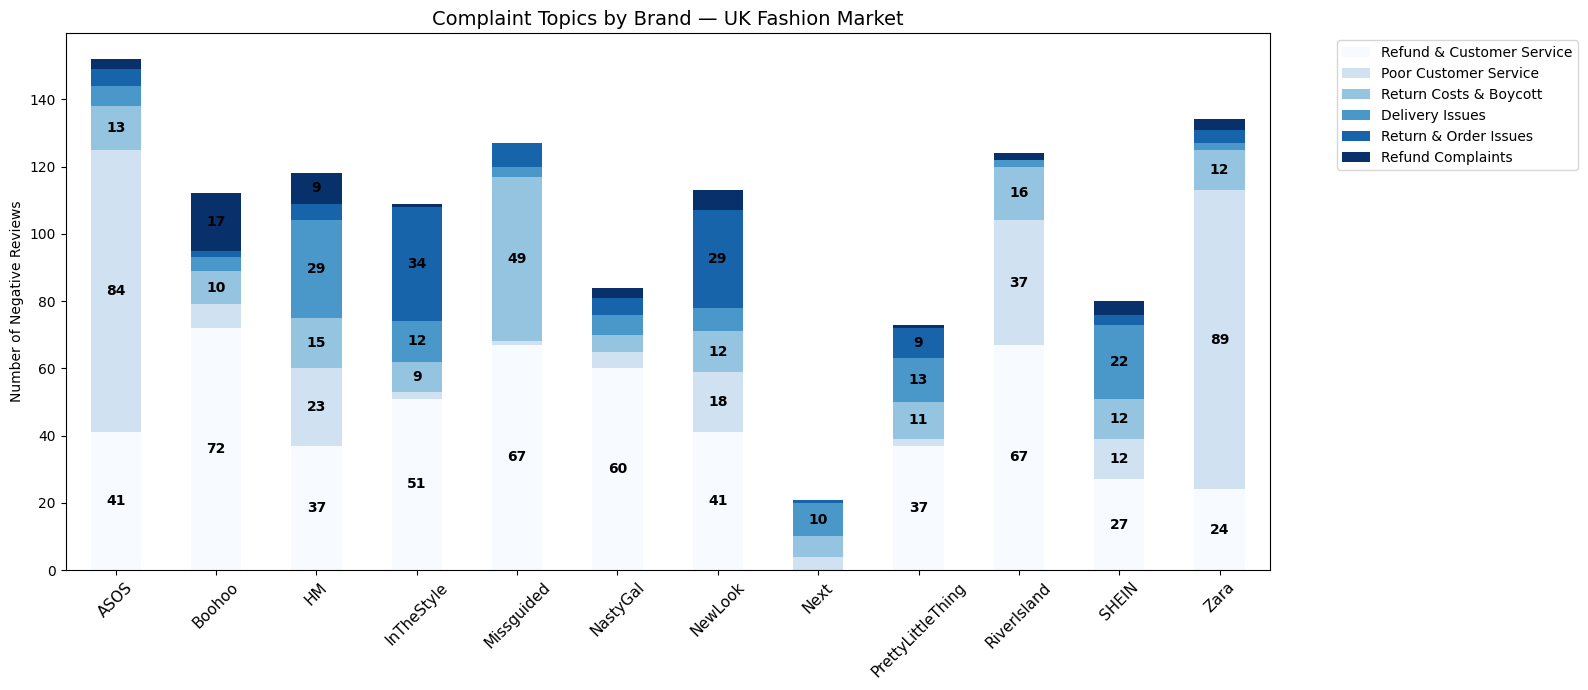

In [28]:
cols = ["Refund & Customer Service", "Poor Customer Service",
        "Return Costs & Boycott", "Delivery Issues",
        "Return & Order Issues", "Refund Complaints"]

brand_topics = brand_topics.reindex(columns=cols, fill_value=0)

fig, ax = plt.subplots(figsize=(16, 7))
brand_topics.plot(kind="bar", stacked=True, colormap="Blues", ax=ax)

for container in ax.containers:
    labels = [int(v) if v >= 8 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels,
                 label_type="center", fontsize=10, fontweight="bold")

ax.set_title("Complaint Topics by Brand — UK Fashion Market", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("Number of Negative Reviews")
ax.tick_params(axis="x", rotation=45, labelsize=11)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()